In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv("credit_card.csv")
df

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0
...,...,...,...,...,...,...,...,...,...,...
9995,9996,350.91,22,Food,0,0,99,4,37,0
9996,9997,410.04,5,Clothing,0,0,70,3,25,0
9997,9998,527.75,21,Electronics,0,0,44,2,45,0
9998,9999,91.20,2,Electronics,0,0,38,0,37,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [ ]:
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [ ]:
df.tail()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
9995,9996,350.91,22,Food,0,0,99,4,37,0
9996,9997,410.04,5,Clothing,0,0,70,3,25,0
9997,9998,527.75,21,Electronics,0,0,44,2,45,0
9998,9999,91.20,2,Electronics,0,0,38,0,37,0
9999,10000,44.06,2,Clothing,0,0,38,0,66,0


In [ ]:
df.describe()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,10000.00000,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


In [ ]:
df.isnull().sum()

,0
transaction_id,0
amount,0
transaction_hour,0
merchant_category,0
foreign_transaction,0
location_mismatch,0
device_trust_score,0
velocity_last_24h,0
cardholder_age,0
is_fraud,0


In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
9995,False
9996,False
9997,False
9998,False


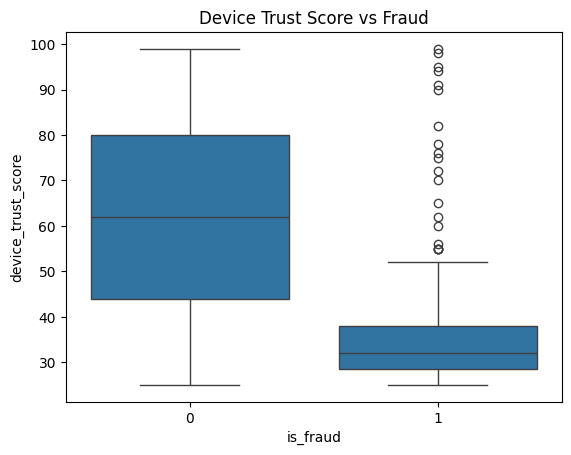

In [ ]:
sns.boxplot(data=df, x="is_fraud", y="device_trust_score")
plt.title("Device Trust Score vs Fraud")
plt.show()

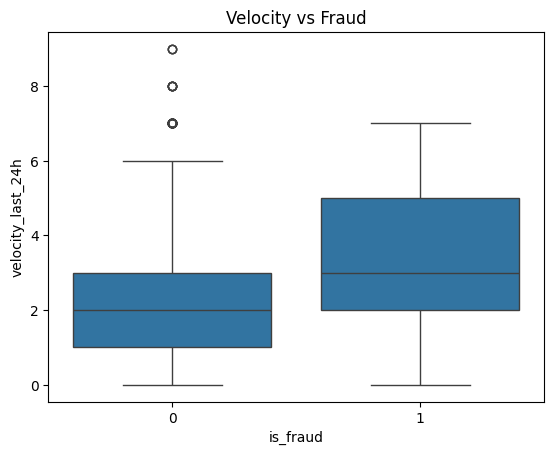

In [ ]:
sns.boxplot(data=df, x="is_fraud", y="velocity_last_24h")
plt.title("Velocity vs Fraud")
plt.show()

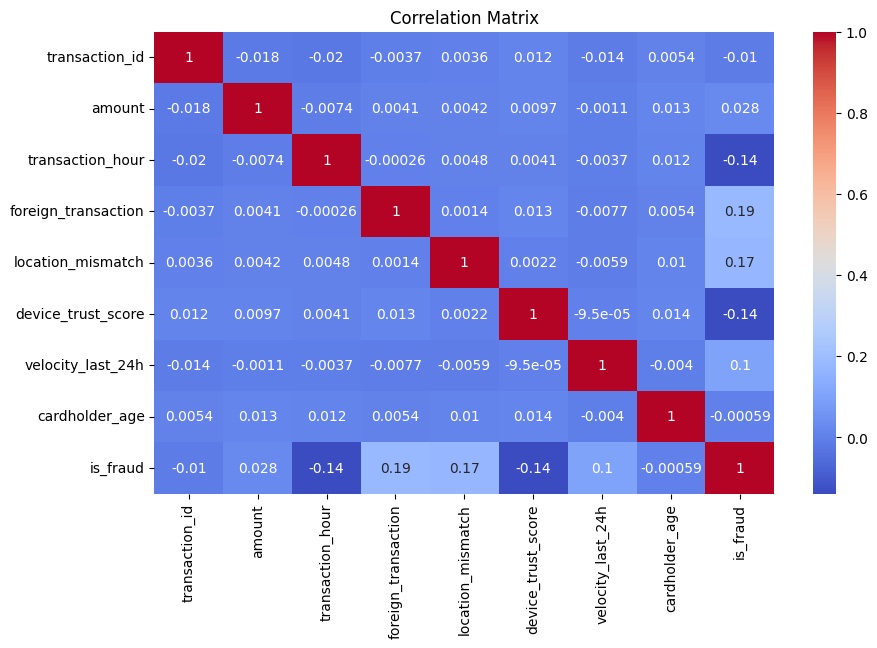

In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


In [ ]:
print(df.dtypes)

transaction_id           int64
amount                 float64
transaction_hour         int64
merchant_category       object
foreign_transaction      int64
location_mismatch        int64
device_trust_score       int64
velocity_last_24h        int64
cardholder_age           int64
is_fraud                 int64
dtype: object


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [ ]:
encoder = LabelEncoder()
df["merchant_category"] = encoder.fit_transform(
    df["merchant_category"]
)

In [ ]:
print(X.select_dtypes(include="object").columns)

Index([], dtype='object')


In [ ]:
X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Accuracy :", accuracy_score(y_test, lr_pred))

Accuracy : 0.992


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Accuracy :", accuracy_score(y_test, dt_pred))

Accuracy : 0.9995


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, rf_pred))

Accuracy : 0.998


In [ ]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

print("Accuracy :", accuracy_score(y_test, nb_pred))

Accuracy : 0.9795


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

print("Accuracy :", accuracy_score(y_test, knn_pred))

Accuracy : 0.9885


In [ ]:
from sklearn.svm import SVC

svm = SVC(probability=True)

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

print("Accuracy :", accuracy_score(y_test, svm_pred))

Accuracy : 0.991


In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,

)

In [ ]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       1.00      0.87      0.93        30

    accuracy                           1.00      2000
   macro avg       1.00      0.93      0.96      2000
weighted avg       1.00      1.00      1.00      2000



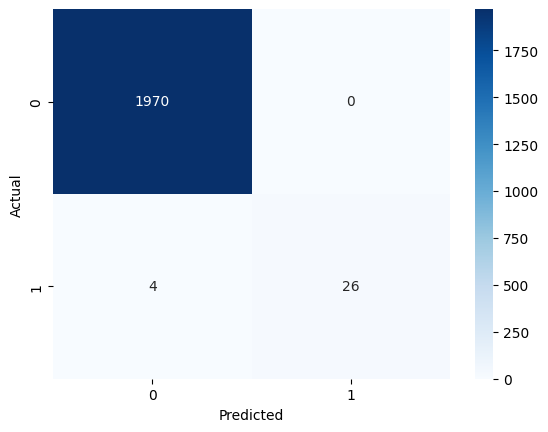

In [ ]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
import pandas as pd

# -------- User Input --------

transaction_id = int(input("Enter Transaction ID: "))
amount = float(input("Enter Amount: "))
transaction_hour = int(input("Enter Transaction Hour (0-23): "))

merchant_category = input(
    "Enter Merchant Category (Food, Shopping, Travel, Electronics, Healthcare): "
)

foreign_transaction = int(input("Foreign Transaction (0=No, 1=Yes): "))
location_mismatch = int(input("Location Mismatch (0=No, 1=Yes): "))
device_trust_score = float(input("Device Trust Score: "))
velocity_last_24h = int(input("Transactions in Last 24 Hours: "))
cardholder_age = int(input("Cardholder Age: "))

# Encode categorical column
merchant_category = encoder.transform([merchant_category])[0]

# Create DataFrame
input_df = pd.DataFrame({
    "transaction_id": [transaction_id],
    "amount": [amount],
    "transaction_hour": [transaction_hour],
    "merchant_category": [merchant_category],
    "foreign_transaction": [foreign_transaction],
    "location_mismatch": [location_mismatch],
    "device_trust_score": [device_trust_score],
    "velocity_last_24h": [velocity_last_24h],
    "cardholder_age": [cardholder_age]
})

# Scale data
scaled_data = scaler.transform(input_df)

# Prediction
prediction = rf.predict(scaled_data)[0]
probability = rf.predict_proba(scaled_data)[0]

# Output
print("\nPrediction Result")

if prediction == 1:
    print("🚨 Fraudulent Transaction")
    print(f"Fraud Probability: {probability[1]*100:.2f}%")
else:
    print("✅ Genuine Transaction")
    print(f"Genuine Probability: {probability[0]*100:.2f}%")

Enter Transaction ID: 50
Enter Amount: 70000
Enter Transaction Hour (0-23): 8
Enter Merchant Category (Food, Shopping, Travel, Electronics, Healthcare): Food
Foreign Transaction (0=No, 1=Yes): 0
Location Mismatch (0=No, 1=Yes): 0
Device Trust Score: 90
Transactions in Last 24 Hours: 80
Cardholder Age: 70

Prediction Result
✅ Genuine Transaction
Genuine Probability: 96.00%


In [ ]:
import joblib
joblib.dump(rf, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(encoder, 'encoder.pkl')

['encoder.pkl']